# Step 2: Train U-Net for Real-Time Segmentation

This notebook implements the second stage of the pipeline:
1. **Define the U-Net architecture** – a lightweight encoder-decoder model
2. **Load the dataset** created in Notebook 01 (raw images + SAM2 binary masks)
3. **Train the U-Net** to replicate SAM2's segmentation at real-time speed
4. **Evaluate** using Dice score and pixel accuracy
5. **Save** the trained model checkpoint

The key insight: SAM2 produces excellent masks but is too slow for real-time robotics. We train a fast U-Net to mimic SAM2's output.

## 2.1 Imports & Configuration

In [77]:
# Uncomment to install dependencies if needed
# !pip install torch torchvision numpy matplotlib Pillow

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms.functional as TF

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.backends.mps.is_available()}")

PyTorch version: 2.6.0
CUDA available: False
MPS available: True


In [9]:
# ============================================================
# CONFIGURATION
# ============================================================

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Dataset paths – use the dataset created in Notebook 01,
# OR use the original project's pre-existing dataset
USE_PIPELINE_DATASET = True  # Set True if you ran Notebook 01

if USE_PIPELINE_DATASET:
    IMAGE_DIR = os.path.join(PROJECT_ROOT, "pipeline", "dataset", "raw_images")
    MASK_DIR = os.path.join(PROJECT_ROOT, "pipeline", "dataset", "binary_masks")
else:
    # Use original project data
    IMAGE_DIR = os.path.join(PROJECT_ROOT, "Data", "Two Handed Task", "raw_images")
    MASK_DIR = os.path.join(PROJECT_ROOT, "Data", "Two Handed Task", "binary_masks")

# Model save path
SAVE_DIR = os.path.join(PROJECT_ROOT, "pipeline", "saved_models")
os.makedirs(SAVE_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(SAVE_DIR, "unet_trained.pth")

# Training hyperparameters
NUM_EPOCHS = 100
BATCH_SIZE = 4
LEARNING_RATE = 1e-4
INPUT_SIZE = (256, 256)
TRAIN_SPLIT = 0.75  # 75% train, 25% validation
VALIDATE_EVERY = 10  # Validate every N epochs

# Device
device = torch.device("cuda" if torch.cuda.is_available() else 
                      "mps" if torch.backends.mps.is_available() else "cpu")

print(f"Device: {device}")
print(f"Image directory: {IMAGE_DIR}")
print(f"Mask directory: {MASK_DIR}")
print(f"Checkpoint will be saved to: {CHECKPOINT_PATH}")

Device: mps
Image directory: /Users/vinithlankireddy/LAB/Gen ai/Real-Time-Video-Segmentation-for-Autonomous-Manipulation-main/pipeline/dataset/raw_images
Mask directory: /Users/vinithlankireddy/LAB/Gen ai/Real-Time-Video-Segmentation-for-Autonomous-Manipulation-main/pipeline/dataset/binary_masks
Checkpoint will be saved to: /Users/vinithlankireddy/LAB/Gen ai/Real-Time-Video-Segmentation-for-Autonomous-Manipulation-main/pipeline/saved_models/unet_trained.pth


## 2.2 Data Transforms & Dataset

We define a custom transform that resizes both image and mask to 256×256, and a PyTorch `Dataset` class that loads image-mask pairs.

In [10]:
class SegmentationTransform:
    """Transform for segmentation: resize + convert to tensor.
    
    Both image and mask are resized to the same dimensions.
    Mask uses nearest-neighbor interpolation to preserve binary values.
    """
    def __init__(self, size=(256, 256)):
        self.size = size
    
    def __call__(self, image, mask):
        # Resize
        image = TF.resize(image, self.size)
        mask = TF.resize(mask, self.size, interpolation=Image.NEAREST)
        
        # Convert to tensor
        image = TF.to_tensor(image)  # [C, H, W], values in [0, 1]
        mask = TF.to_tensor(mask)    # [1, H, W], values in {0, 1}
        
        return image, mask

In [11]:
class SegmentationDataset(Dataset):
    """Dataset for loading image-mask pairs.
    
    Expects matching filenames in image_dir and mask_dir.
    Images are loaded as RGB, masks as grayscale.
    """
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.image_names = sorted(os.listdir(image_dir))
        
        # Filter to only include files that have corresponding masks
        self.image_names = [
            name for name in self.image_names 
            if os.path.exists(os.path.join(mask_dir, name))
        ]
        print(f"Dataset: {len(self.image_names)} image-mask pairs")

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_names[idx])
        mask_path = os.path.join(self.mask_dir, self.image_names[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if self.transform:
            image, mask = self.transform(image, mask)

        return image, mask

## 2.3 U-Net Architecture

The U-Net is a lightweight encoder-decoder architecture with skip connections:

```
Input (3, 256, 256)
  │
  ▼
Encoder Block 1: Conv(3→64) + Conv(64→64)     ──────────┐
  │ MaxPool2d(2)                                          │
  ▼                                                       │
Encoder Block 2: Conv(64→128) + Conv(128→128)  ────────┐ │
  │ MaxPool2d(2)                                        │ │
  ▼                                                     │ │
Bridge: Conv(128→256) + Conv(256→256)                   │ │
  │                                                     │ │
  ▼ ConvTranspose2d(256→128)                            │ │
Decoder Block 2: Concat + Conv(256→128) + Conv  ←──────┘ │
  │                                                       │
  ▼ ConvTranspose2d(128→64)                               │
Decoder Block 1: Concat + Conv(128→64) + Conv   ←────────┘
  │
  ▼ Conv2d(64→1) + Sigmoid
Output (1, 256, 256)
```

In [12]:
class UNet(nn.Module):
    """Lightweight U-Net for binary segmentation.
    
    Architecture:
        - 2 encoder blocks with max-pooling
        - 1 bridge block 
        - 2 decoder blocks with transposed convolution + skip connections
        - 1x1 convolution output with sigmoid activation
    """
    def __init__(self):
        super(UNet, self).__init__()

        def conv_block(in_channels, out_channels):
            """Two consecutive 3x3 convolutions with ReLU."""
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, 3, padding=1),
                nn.ReLU(inplace=True),
            )

        # Encoder (downsampling path)
        self.down1 = conv_block(3, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        # Bridge (bottleneck)
        self.bridge = conv_block(128, 256)

        # Decoder (upsampling path)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.up_block2 = conv_block(256, 128)  # 256 = 128 (upsampled) + 128 (skip)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.up_block1 = conv_block(128, 64)   # 128 = 64 (upsampled) + 64 (skip)

        # Output layer
        self.out = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        # Encoder
        d1 = self.down1(x)              # (B, 64, 256, 256)
        d2 = self.down2(self.pool1(d1)) # (B, 128, 128, 128)
        
        # Bridge
        b = self.bridge(self.pool2(d2)) # (B, 256, 64, 64)
        
        # Decoder with skip connections
        u2 = self.up_block2(torch.cat([self.up2(b), d2], dim=1))  # (B, 128, 128, 128)
        u1 = self.up_block1(torch.cat([self.up1(u2), d1], dim=1)) # (B, 64, 256, 256)
        
        return torch.sigmoid(self.out(u1))  # (B, 1, 256, 256)

In [13]:
# Instantiate model and print summary
model = UNet().to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"U-Net Model Summary:")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model size: ~{total_params * 4 / 1024 / 1024:.1f} MB (float32)")
print(f"  Device: {device}")

# Test forward pass
dummy_input = torch.randn(1, 3, 256, 256).to(device)
dummy_output = model(dummy_input)
print(f"\n  Input shape:  {dummy_input.shape}")
print(f"  Output shape: {dummy_output.shape}")
print(f"  Output range: [{dummy_output.min().item():.4f}, {dummy_output.max().item():.4f}]")

U-Net Model Summary:
  Total parameters:     1,862,849
  Trainable parameters: 1,862,849
  Model size: ~7.1 MB (float32)
  Device: mps

  Input shape:  torch.Size([1, 3, 256, 256])
  Output shape: torch.Size([1, 1, 256, 256])
  Output range: [0.4652, 0.4772]


## 2.4 Setup Dataset & DataLoaders

In [14]:
# Create dataset
transform = SegmentationTransform(size=INPUT_SIZE)
dataset = SegmentationDataset(IMAGE_DIR, MASK_DIR, transform=transform)

# Optional: subsample frames (e.g., take every 3rd frame)
# This mimics the original project's approach of subsampling 30fps to 10fps
FRAME_SKIP = 3  # Set to 1 to use all frames
subset_indices = list(range(0, len(dataset), FRAME_SKIP))
dataset = Subset(dataset, subset_indices)
print(f"After subsampling (every {FRAME_SKIP}th frame): {len(dataset)} samples")

# Train/validation split
n_total = len(dataset)
n_train = int(n_total * TRAIN_SPLIT)
n_val = n_total - n_train

train_dataset = Subset(dataset, list(range(0, n_train)))
val_dataset = Subset(dataset, list(range(n_train, n_total)))

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Dataset: 1560 image-mask pairs
After subsampling (every 3th frame): 520 samples
Training samples: 390
Validation samples: 130
Training batches: 98
Validation batches: 33


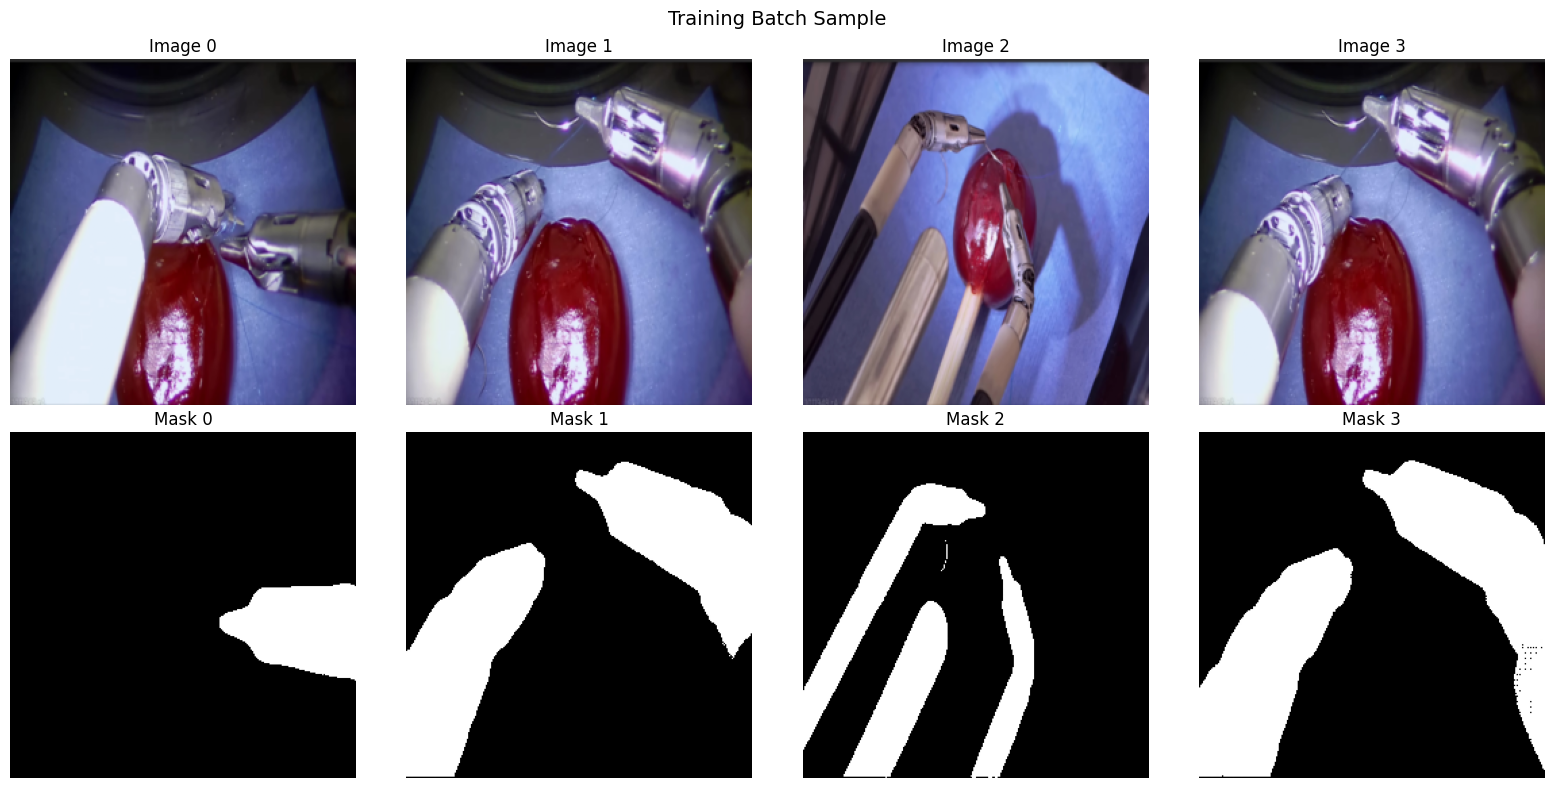

In [15]:
# Visualize a training batch
images, masks = next(iter(train_loader))

fig, axes = plt.subplots(2, min(4, BATCH_SIZE), figsize=(16, 8))
for i in range(min(4, BATCH_SIZE)):
    axes[0, i].imshow(images[i].permute(1, 2, 0).numpy())
    axes[0, i].set_title(f"Image {i}")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(masks[i].squeeze().numpy(), cmap='gray')
    axes[1, i].set_title(f"Mask {i}")
    axes[1, i].axis('off')

plt.suptitle("Training Batch Sample", fontsize=14)
plt.tight_layout()
plt.show()

## 2.5 Training Utilities

In [16]:
def dice_score(pred, target, epsilon=1e-6):
    """Compute Dice score (2 * intersection / union).
    
    Dice = 1.0 means perfect overlap, 0.0 means no overlap.
    """
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()
    return (2.0 * intersection + epsilon) / (union + epsilon)

## 2.6 Training Loop

We train using **Binary Cross-Entropy (BCE)** loss and track both loss and **Dice score** as our primary metric.

In [17]:
# Training setup
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# History for plotting
history = {
    'train_loss': [],
    'train_dice': [],
    'val_loss': [],
    'val_dice': [],
    'val_epochs': []
}

print(f"Starting training for {NUM_EPOCHS} epochs...")
print(f"Loss function: BCELoss")
print(f"Optimizer: Adam (lr={LEARNING_RATE})")
print(f"Validation every {VALIDATE_EVERY} epochs")
print("-" * 70)

Starting training for 100 epochs...
Loss function: BCELoss
Optimizer: Adam (lr=0.0001)
Validation every 10 epochs
----------------------------------------------------------------------


In [18]:
for epoch in range(NUM_EPOCHS):
    # ---- Training Phase ----
    model.train()
    train_loss = 0
    train_dice_sum = 0
    num_batches = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, masks)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        preds = (outputs > 0.5).float()
        batch_dice = dice_score(preds, masks)

        train_loss += loss.item()
        train_dice_sum += batch_dice.item()
        num_batches += 1

    avg_train_loss = train_loss / num_batches
    avg_train_dice = train_dice_sum / num_batches
    history['train_loss'].append(avg_train_loss)
    history['train_dice'].append(avg_train_dice)

    print(f"Epoch [{epoch+1:3d}/{NUM_EPOCHS}]  "
          f"Train Loss: {avg_train_loss:.4f}  "
          f"Train Dice: {avg_train_dice:.4f}", end="")

    # ---- Validation Phase (every N epochs) ----
    if (epoch + 1) % VALIDATE_EVERY == 0:
        model.eval()
        val_loss = 0
        val_dice_sum = 0
        num_val_batches = 0

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)
                loss = criterion(outputs, masks)

                preds = (outputs > 0.5).float()
                batch_dice = dice_score(preds, masks)

                val_loss += loss.item()
                val_dice_sum += batch_dice.item()
                num_val_batches += 1

        avg_val_loss = val_loss / num_val_batches
        avg_val_dice = val_dice_sum / num_val_batches
        history['val_loss'].append(avg_val_loss)
        history['val_dice'].append(avg_val_dice)
        history['val_epochs'].append(epoch + 1)

        print(f"  |  Val Loss: {avg_val_loss:.4f}  Val Dice: {avg_val_dice:.4f}")
    else:
        print()

print("-" * 70)
print("Training complete!")

Epoch [  1/100]  Train Loss: 0.3944  Train Dice: 0.0000
Epoch [  2/100]  Train Loss: 0.2309  Train Dice: 0.0000
Epoch [  3/100]  Train Loss: 0.1905  Train Dice: 0.0000
Epoch [  4/100]  Train Loss: 0.1645  Train Dice: 0.5341
Epoch [  5/100]  Train Loss: 0.1507  Train Dice: 0.6169
Epoch [  6/100]  Train Loss: 0.1450  Train Dice: 0.6231
Epoch [  7/100]  Train Loss: 0.1335  Train Dice: 0.6713
Epoch [  8/100]  Train Loss: 0.1321  Train Dice: 0.6609
Epoch [  9/100]  Train Loss: 0.1276  Train Dice: 0.6783
Epoch [ 10/100]  Train Loss: 0.1211  Train Dice: 0.6947  |  Val Loss: 0.1806  Val Dice: 0.6911
Epoch [ 11/100]  Train Loss: 0.1144  Train Dice: 0.7146
Epoch [ 12/100]  Train Loss: 0.1126  Train Dice: 0.7229
Epoch [ 13/100]  Train Loss: 0.1075  Train Dice: 0.7319
Epoch [ 14/100]  Train Loss: 0.1003  Train Dice: 0.7530
Epoch [ 15/100]  Train Loss: 0.0992  Train Dice: 0.7536
Epoch [ 16/100]  Train Loss: 0.0944  Train Dice: 0.7708
Epoch [ 17/100]  Train Loss: 0.0961  Train Dice: 0.7646
Epoch [ 1

## 2.7 Save Model Checkpoint

In [19]:
# Save trained model weights
torch.save(model.state_dict(), CHECKPOINT_PATH)
print(f"Model saved to: {CHECKPOINT_PATH}")

# Print file size
size_mb = os.path.getsize(CHECKPOINT_PATH) / 1024 / 1024
print(f"Checkpoint size: {size_mb:.1f} MB")

Model saved to: /Users/vinithlankireddy/LAB/Gen ai/Real-Time-Video-Segmentation-for-Autonomous-Manipulation-main/pipeline/saved_models/unet_trained.pth
Checkpoint size: 7.1 MB


## 2.8 Training Curves

Visualize the loss and Dice score over training epochs.

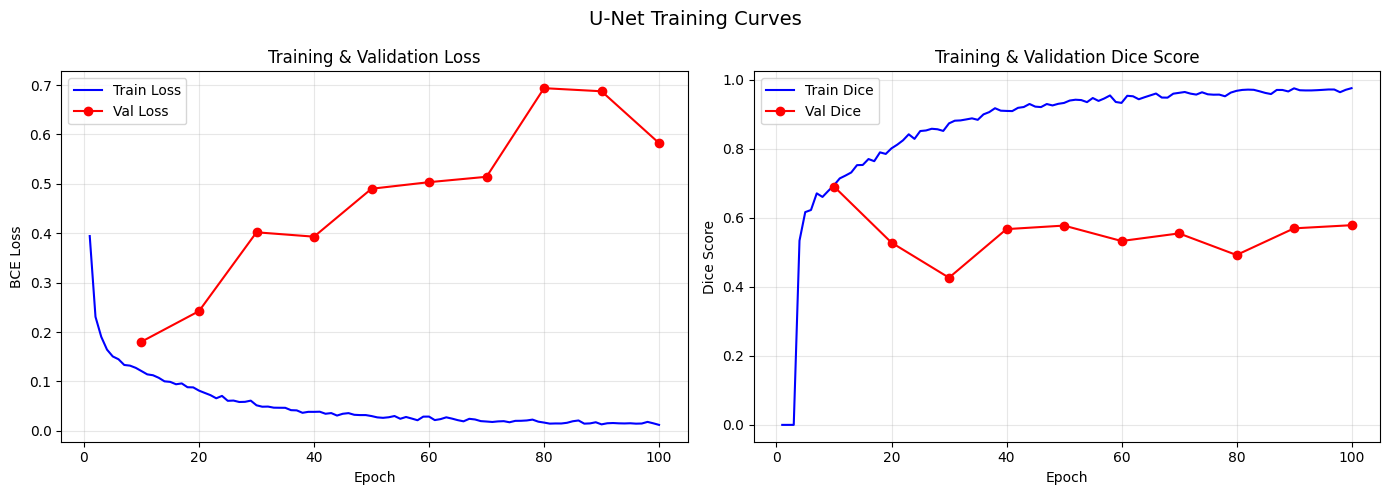


Final Training Loss: 0.0122
Final Training Dice: 0.9762
Final Validation Loss: 0.5826
Final Validation Dice: 0.5790


In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(range(1, NUM_EPOCHS + 1), history['train_loss'], label='Train Loss', color='blue')
if history['val_loss']:
    ax1.plot(history['val_epochs'], history['val_loss'], label='Val Loss', color='red', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Dice curves
ax2.plot(range(1, NUM_EPOCHS + 1), history['train_dice'], label='Train Dice', color='blue')
if history['val_dice']:
    ax2.plot(history['val_epochs'], history['val_dice'], label='Val Dice', color='red', marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Dice Score')
ax2.set_title('Training & Validation Dice Score')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('U-Net Training Curves', fontsize=14)
plt.tight_layout()
plt.show()

# Print final metrics
print(f"\nFinal Training Loss: {history['train_loss'][-1]:.4f}")
print(f"Final Training Dice: {history['train_dice'][-1]:.4f}")
if history['val_loss']:
    print(f"Final Validation Loss: {history['val_loss'][-1]:.4f}")
    print(f"Final Validation Dice: {history['val_dice'][-1]:.4f}")

## 2.9 Evaluation on Validation Set

In [21]:
# Full evaluation on validation set
model.eval()
all_dice = []
all_acc = []

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        preds = (outputs > 0.5).float()

        # Dice score
        d = dice_score(preds, masks)
        all_dice.append(d.item())

        # Pixel accuracy
        acc = (preds == masks).float().mean().item()
        all_acc.append(acc)

avg_dice = np.mean(all_dice)
avg_acc = np.mean(all_acc)

print(f"Validation Results:")
print(f"  Pixel Accuracy: {avg_acc:.4f} ({avg_acc*100:.1f}%)")
print(f"  Dice Score:     {avg_dice:.4f}")

Validation Results:
  Pixel Accuracy: 0.9289 (92.9%)
  Dice Score:     0.5790


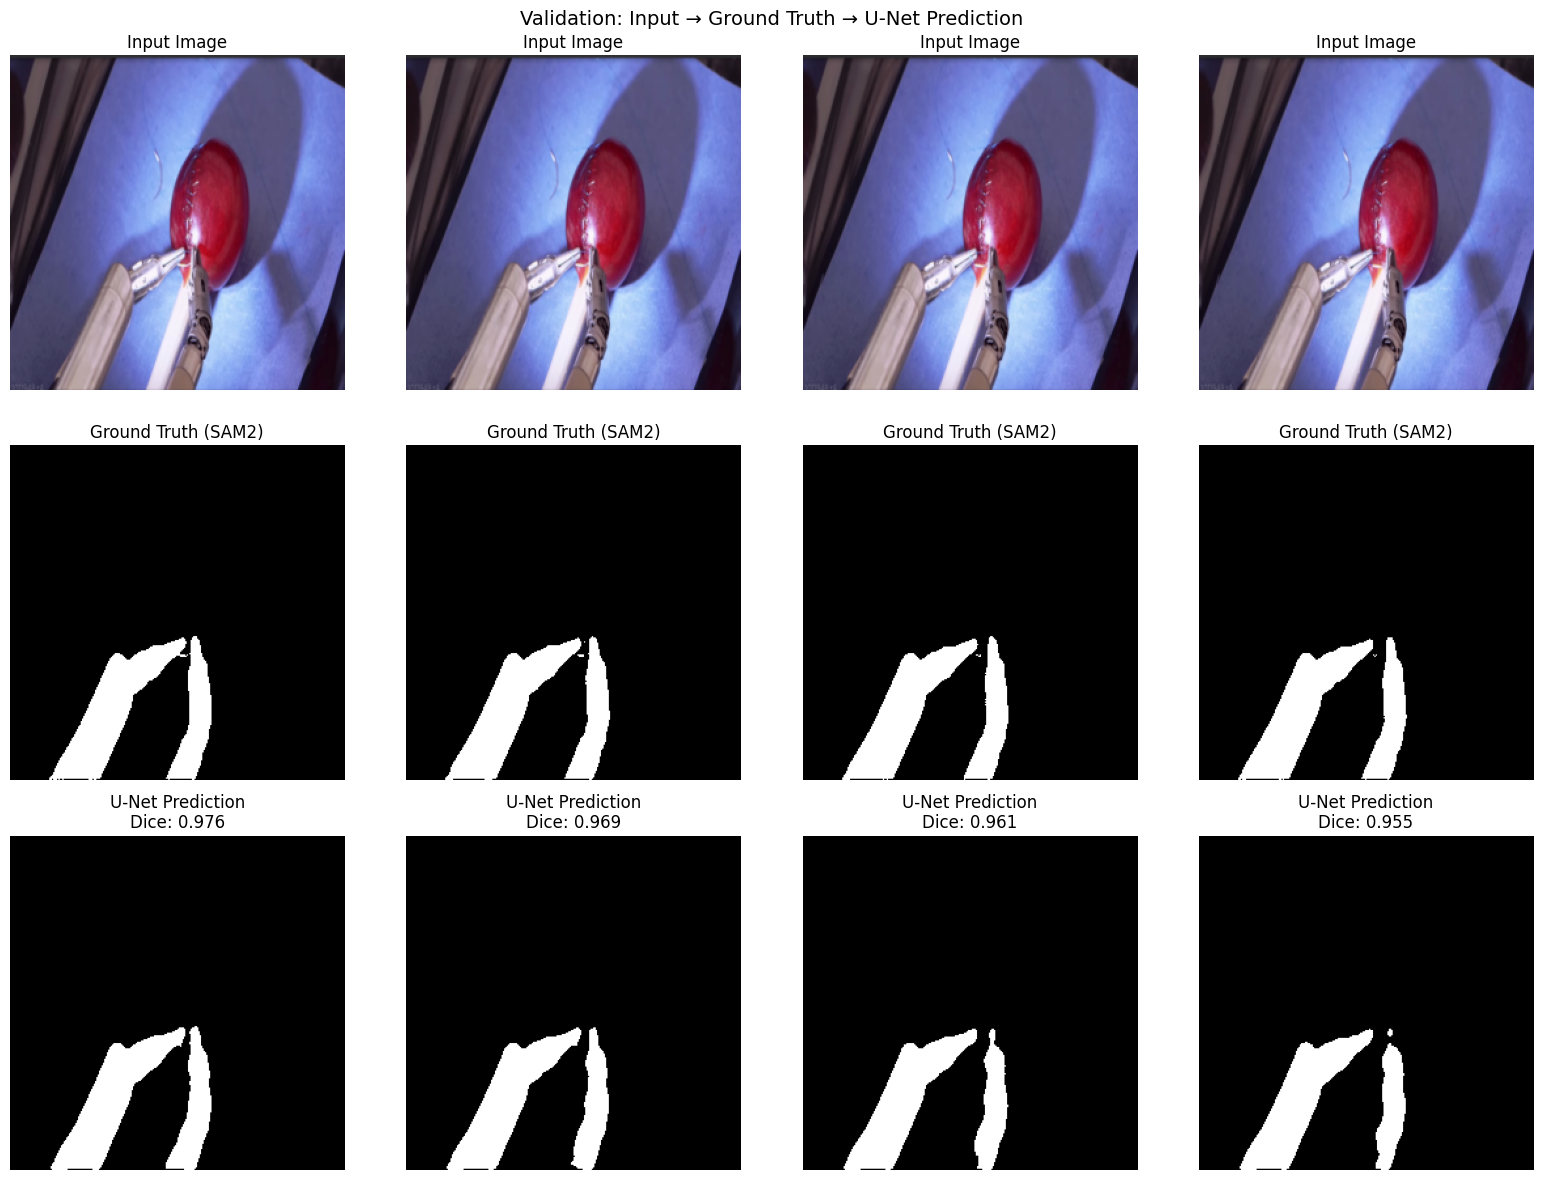


Model is ready! Proceed to Notebook 03 for inference and results.


In [22]:
# Visualize predictions on validation samples
model.eval()
val_images, val_masks = next(iter(val_loader))
val_images = val_images.to(device)

with torch.no_grad():
    val_preds = model(val_images)

n_show = min(4, len(val_images))
fig, axes = plt.subplots(3, n_show, figsize=(16, 12))

for i in range(n_show):
    # Original image
    axes[0, i].imshow(val_images[i].cpu().permute(1, 2, 0).numpy())
    axes[0, i].set_title("Input Image")
    axes[0, i].axis('off')

    # Ground truth mask
    axes[1, i].imshow(val_masks[i].squeeze().numpy(), cmap='gray')
    axes[1, i].set_title("Ground Truth (SAM2)")
    axes[1, i].axis('off')

    # Predicted mask
    pred = (val_preds[i] > 0.5).float().squeeze().cpu().numpy()
    axes[2, i].imshow(pred, cmap='gray')
    d = dice_score(val_preds[i].cpu(), val_masks[i])
    axes[2, i].set_title(f"U-Net Prediction\nDice: {d:.3f}")
    axes[2, i].axis('off')

plt.suptitle('Validation: Input → Ground Truth → U-Net Prediction', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nModel is ready! Proceed to Notebook 03 for inference and results.")